### 손가락 숫자 모양의 이미지 분류

https://drive.google.com/file/d/1E8IPKBjSLF9UN9UZQtaI0slHScXZcMr2/view?usp=sharing

In [6]:
import glob
import matplotlib.pyplot as plt
from PIL import Image

In [17]:
# 파일명 불러오기 : 파일명에 target 값이 들어있음
train_images = glob.glob("../Data/fingers/train/*.png")
test_images = glob.glob('../Data/fingers/test/*.png')

In [18]:
# file name 확인
test_images[:5]

['../Data/fingers/test\\000e7aa6-100b-4c6b-9ff0-e7a8e53e4465_5L.png',
 '../Data/fingers/test\\001f6021-8581-4ed2-aed4-cda0af1d5d57_5L.png',
 '../Data/fingers/test\\0027029b-4c3c-4785-bc1b-b8141331a108_3R.png',
 '../Data/fingers/test\\004599fb-c735-4ff3-a969-342dda319382_5L.png',
 '../Data/fingers/test\\00500e1a-f4bd-4f66-9eb8-c7fce19a3f6f_5L.png']

In [19]:
train_input = []
test_input = []
train_target = []
test_target = []


# train data
for image in sorted(train_images):
    img = Image.open(image)
    imgResize = img.resize((32,32), Image.Resampling.LANCZOS)
    train_input.append(imgResize)
    train_target.append(image[-6:-4])

# test data
for image in sorted(test_images):
    img = Image.open(image)
    imgResize = img.resize((32,32), Image.Resampling.LANCZOS)
    test_input.append(imgResize)
    test_target.append(image[-6:-4])

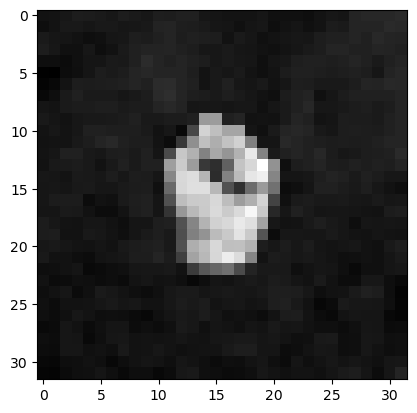

In [20]:
# train의 이미지 확인
plt.imshow(train_input[0], cmap='gray')
plt.show()

----
#### Numpy 배열로 변경

In [4]:
import numpy as np

In [22]:
# train data 만들기 (18000 * 32 *32)

tempData = np.zeros(
            18000 * 32 * 32,
            dtype = np.int32
).reshape(18000, 32, 32)

i = 0
for image in train_input:
    img = np.array(image, dtype=np.int32)
    tempData[i, :, :] = img
    i += 1

train_input = tempData.copy()

In [23]:
# test data 만들기 (3600 * 32 *32)

tempData = np.zeros(
            3600 * 32 * 32,
            dtype = np.int32
).reshape(3600, 32, 32)

i = 0
for image in test_input:
    img = np.array(image, dtype=np.int32)
    tempData[i, :, :] = img
    i += 1

test_input = tempData.copy()

----
#### Target을 숫자로 변경하기

In [24]:
label_to_int = {
    '0R' : 0,
    '1R' : 1,
    '2R' : 2,
    '3R' : 3,
    '4R' : 4,
    '5R' : 5,
    '0L' : 6,
    '1L' : 7,
    '2L' : 8,
    '3L' : 9,
    '4L' : 10,
    '5L' : 11,
}

In [ ]:
# 숫자로 변경

temp =[]
for label in train_target:
    temp.append(label_to_int[label])

train_target = temp.copy()

In [27]:
train_target

[6,
 6,
 8,
 6,
 11,
 5,
 2,
 2,
 9,
 0,
 10,
 8,
 6,
 7,
 2,
 3,
 6,
 9,
 5,
 5,
 4,
 6,
 2,
 2,
 0,
 11,
 6,
 6,
 9,
 3,
 8,
 7,
 0,
 6,
 11,
 10,
 7,
 0,
 4,
 10,
 11,
 1,
 2,
 2,
 11,
 9,
 9,
 4,
 11,
 3,
 2,
 2,
 2,
 8,
 5,
 0,
 5,
 5,
 2,
 8,
 4,
 3,
 5,
 0,
 6,
 10,
 7,
 0,
 8,
 0,
 7,
 11,
 6,
 4,
 8,
 9,
 7,
 0,
 3,
 2,
 2,
 0,
 1,
 0,
 11,
 1,
 1,
 7,
 2,
 2,
 7,
 2,
 2,
 11,
 3,
 4,
 7,
 0,
 5,
 8,
 1,
 11,
 11,
 5,
 2,
 10,
 8,
 10,
 0,
 8,
 11,
 3,
 9,
 1,
 1,
 1,
 5,
 7,
 10,
 4,
 0,
 4,
 3,
 8,
 11,
 2,
 1,
 8,
 3,
 8,
 8,
 1,
 4,
 11,
 9,
 1,
 7,
 4,
 2,
 11,
 8,
 6,
 4,
 7,
 6,
 1,
 5,
 2,
 10,
 8,
 5,
 10,
 1,
 9,
 1,
 2,
 1,
 6,
 5,
 4,
 11,
 0,
 0,
 6,
 11,
 7,
 6,
 1,
 5,
 10,
 1,
 6,
 4,
 8,
 9,
 5,
 4,
 0,
 0,
 11,
 8,
 9,
 1,
 3,
 0,
 6,
 6,
 0,
 11,
 7,
 2,
 10,
 0,
 4,
 1,
 9,
 1,
 8,
 9,
 0,
 9,
 6,
 11,
 3,
 10,
 8,
 1,
 10,
 10,
 6,
 6,
 0,
 5,
 3,
 1,
 2,
 10,
 5,
 10,
 10,
 6,
 4,
 3,
 9,
 10,
 7,
 8,
 9,
 2,
 0,
 9,
 4,
 5,
 10,
 0,
 9,
 3,
 5,
 4,
 11,


In [ ]:
# 숫자로 변경

temp =[]
for label in test_target:
    temp.append(label_to_int[label])

test_target = temp.copy()

In [29]:
test_target

[11,
 11,
 3,
 11,
 11,
 4,
 2,
 4,
 11,
 4,
 7,
 6,
 5,
 1,
 11,
 7,
 6,
 11,
 0,
 5,
 3,
 5,
 3,
 10,
 10,
 7,
 3,
 0,
 1,
 3,
 3,
 6,
 3,
 10,
 1,
 3,
 0,
 0,
 8,
 3,
 2,
 10,
 9,
 11,
 3,
 11,
 1,
 0,
 11,
 7,
 0,
 10,
 7,
 2,
 11,
 11,
 7,
 4,
 2,
 3,
 9,
 11,
 9,
 11,
 0,
 3,
 1,
 5,
 0,
 8,
 11,
 10,
 9,
 9,
 3,
 11,
 7,
 3,
 2,
 5,
 10,
 1,
 9,
 5,
 8,
 8,
 6,
 9,
 2,
 9,
 11,
 8,
 3,
 4,
 7,
 1,
 10,
 0,
 11,
 9,
 8,
 4,
 5,
 4,
 0,
 8,
 4,
 7,
 6,
 10,
 0,
 0,
 3,
 2,
 10,
 3,
 8,
 11,
 10,
 3,
 8,
 10,
 9,
 3,
 11,
 7,
 6,
 3,
 3,
 11,
 3,
 3,
 11,
 5,
 6,
 8,
 1,
 2,
 11,
 1,
 0,
 10,
 7,
 0,
 1,
 5,
 11,
 3,
 11,
 10,
 11,
 2,
 9,
 10,
 4,
 8,
 2,
 2,
 0,
 11,
 10,
 2,
 1,
 4,
 11,
 0,
 10,
 1,
 2,
 3,
 5,
 6,
 1,
 2,
 4,
 5,
 3,
 2,
 8,
 6,
 2,
 3,
 3,
 8,
 1,
 10,
 4,
 2,
 0,
 8,
 7,
 1,
 6,
 9,
 11,
 8,
 4,
 0,
 4,
 3,
 1,
 5,
 8,
 5,
 0,
 9,
 3,
 0,
 7,
 10,
 9,
 5,
 11,
 1,
 11,
 5,
 4,
 9,
 8,
 8,
 6,
 2,
 9,
 7,
 5,
 9,
 10,
 1,
 8,
 2,
 2,
 10,
 9,
 0,
 6,
 10,
 7,

In [32]:
# target data도 numpy array로 변경
train_target = np.array(train_target)
test_target = np.array(test_target)

test_target[:5]

array([11, 11,  3, 11, 11])

----
#### 인공신경망 적용

##### train / valid 분리

In [37]:
from sklearn.model_selection import train_test_split

In [ ]:
train_scaled = train_input / 255.0
test_scaled = test_input / 255.0

array([[[0.2       , 0.20392157, 0.21568627, ..., 0.25882353,
         0.25882353, 0.26666667],
        [0.18823529, 0.20392157, 0.21960784, ..., 0.25098039,
         0.26666667, 0.2627451 ],
        [0.22352941, 0.21176471, 0.20784314, ..., 0.2627451 ,
         0.25490196, 0.24705882],
        ...,
        [0.18431373, 0.18039216, 0.21176471, ..., 0.2       ,
         0.18823529, 0.19607843],
        [0.17254902, 0.16862745, 0.18823529, ..., 0.19607843,
         0.21176471, 0.21568627],
        [0.16470588, 0.16078431, 0.18039216, ..., 0.18431373,
         0.21176471, 0.25098039]],

       [[0.18823529, 0.17254902, 0.17647059, ..., 0.21960784,
         0.21176471, 0.21176471],
        [0.16862745, 0.18039216, 0.17254902, ..., 0.21176471,
         0.19215686, 0.19607843],
        [0.20392157, 0.17647059, 0.16862745, ..., 0.20392157,
         0.19607843, 0.2       ],
        ...,
        [0.21568627, 0.22745098, 0.20784314, ..., 0.19215686,
         0.19215686, 0.20392157],
        [0.2

In [41]:
train_scaled, val_scaled, train_target, val_target = \
    train_test_split(
        train_scaled,
        train_target,
        test_size= 0.2,
        random_state= 42
    )

In [42]:
print(train_scaled.shape, val_scaled.shape)

(14400, 32, 32) (3600, 32, 32)


----
#### 인공신경망 모델 생성

In [43]:
from tensorflow import keras

In [49]:
model = keras.Sequential()
model.add(keras.layers.Flatten(input_shape = (32, 32)))
model.add(keras.layers.Dense(100, activation='relu', name= 'hidden1'))
model.add(keras.layers.Dense(12, activation='softmax', name= 'output'))

c:\ProgramData\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [50]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)                  │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ hidden1 (Dense)                      │ (None, 100)                 │         102,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output (Dense)                       │ (None, 12)                  │           1,212 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 103,712 (405.12 KB)

 Trainable params: 103,712 (405.12 KB)

 Non-trainable params: 0 (0.00 B)

In [51]:
model.compile(
    loss='sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

----
#### 모델 학습 및 평가

In [52]:
model.fit(
    train_scaled,
    train_target,
    epochs = 10
)

Epoch 1/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7730 - loss: 0.9983
Epoch 2/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9551 - loss: 0.2086
Epoch 3/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9783 - loss: 0.0987
Epoch 4/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9862 - loss: 0.0602
Epoch 5/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9910 - loss: 0.0381
Epoch 6/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9937 - loss: 0.0265
Epoch 7/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9957 - loss: 0.0191
Epoch 8/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9972 - loss: 0.0138
Epoch 9/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9976 - loss: 0.0107
Epoch 10/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9987 - loss: 0.0076


In [53]:
model.evaluate(val_scaled, val_target)

113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9997 - loss: 0.0056


[0.005592318717390299, 0.9997222423553467]

In [54]:
model.evaluate(test_scaled, test_target)

113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9983 - loss: 0.0061


[0.006074640899896622, 0.9983333349227905]

----
#### Keras Tuner
- 수업시간에 한거 아님!

In [58]:
!pip install tensorboard

   ---------------------------------------- 0.0/5.5 MB ? eta -:--:--
   ---------------------------------------- 5.5/5.5 MB 46.7 MB/s  0:00:00

   -------------------- ------------------- 1/2 [tensorboard]
   -------------------- ------------------- 1/2 [tensorboard]
   -------------------- ------------------- 1/2 [tensorboard]
   -------------------- ------------------- 1/2 [tensorboard]
   -------------------- ------------------- 1/2 [tensorboard]
   ---------------------------------------- 2/2 [tensorboard]



In [56]:
!pip install keras-tuner


   -------------------- ------------------- 1/2 [keras-tuner]
   ---------------------------------------- 2/2 [keras-tuner]



In [62]:
import keras_tuner as kt
from tensorflow.keras.callbacks import EarlyStopping

# 1. 모델 빌드 함수 (기존과 동일)
def model_builder(hp):
    model = keras.Sequential()
    hp_units = hp.Int('units', min_value=32, max_value=256, step=32)
    model.add(keras.layers.Flatten(input_shape = (32, 32)))
    model.add(keras.layers.Dense(units=hp_units, activation='relu'))
    model.add(keras.layers.Dense(12, activation='softmax'))
    
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=hp_learning_rate),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# 2. 튜너 설정
tuner = kt.RandomSearch(
    model_builder,
    objective='val_accuracy',
    max_trials=10
)

# 3. ★ 핵심: search 단계에서 batch_size 튜닝하기 ★
# tuner.search 내부에서 즉석으로 hp.Choice를 정의해 줍니다.

# early stopping callback 정의
early_stopping = EarlyStopping(
    monitor='val_loss',          # 검증 손실(val_loss)을 모니터링
    patience=5,                  # 5번의 에포크 동안 val_loss가 개선되지 않으면 조기 종료
    restore_best_weights=True    # 종료 후 가장 성능이 좋았던 시점의 가중치로 복원
)

tuner.search(
    train_scaled, train_target, 
    epochs=100, 
    validation_data=(val_scaled, val_target),
    callbacks=[early_stopping],
    batch_size=tuner.oracle.hyperparameters.Choice('batch_size', values=[32, 64, 128])
)

# 4. 가장 좋은 조합 확인
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"최적의 뉴런 수: {best_hps.get('units')}")
print(f"최적의 학습률: {best_hps.get('learning_rate')}")
print(f"최적의 배치 사이즈: {best_hps.get('batch_size')}") # 이제 이것도 출력 가능!

Trial 10 Complete [00h 00m 21s]
val_accuracy: 1.0

Best val_accuracy So Far: 1.0
Total elapsed time: 00h 06m 50s
최적의 뉴런 수: 32
최적의 학습률: 0.001
최적의 배치 사이즈: 128


In [63]:
# 튜너가 찾은 베스트 모델 꺼내기 (1등 모델 하나만 가져옴)
best_model = tuner.get_best_models(num_models=1)[0]

# 제대로 가져왔는지 구조 확인
best_model.summary()

c:\ProgramData\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:843: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │          32,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 12)                  │             396 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 33,196 (129.67 KB)

 Trainable params: 33,196 (129.67 KB)

 Non-trainable params: 0 (0.00 B)

In [64]:
best_model.evaluate(test_scaled, test_target)

113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9997 - loss: 0.0050


[0.004967324901372194, 0.9997222423553467]

In [65]:
best_model.evaluate(train_scaled, train_target)

450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9999 - loss: 0.0035


[0.003471972420811653, 0.9999305605888367]

In [67]:
# 1등을 한 최적의 Trial 정보 가져오기
best_trial = tuner.oracle.get_best_trials(num_trials=1)[0]

# 해당 Trial이 기록한 가장 좋은 에포크(step) 출력
print(f"🥇 최적의 에포크 횟수: {best_trial.best_step}번")

🥇 최적의 에포크 횟수: 21번
